# Medical Insurance Claim Amount Prediction



The dataset contains:

- **age**: Age of the person
- **sex**: Male or female
- **bmi**: Body Mass Index
- **children**: Number of children
- **smoker**: Whether the person smokes or not
- **region**: Residential region
- **charges**: Medical insurance claim amount

Our target column is **charges**.


## 1. Import Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## 2. Load Dataset

In [8]:
df = pd.read_csv(r"D:\Data Analyst\internship\Medical Cost Personal\insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Check Dataset Information

In [9]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## 4. Check Missing Values

In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Explanation

If missing values exist, we need to clean them before training the model.

In this dataset, usually there are no missing values. But checking missing values is still important in every machine learning project.


## 5. Basic Statistics

In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 6. Visualize Age Impact on Charges

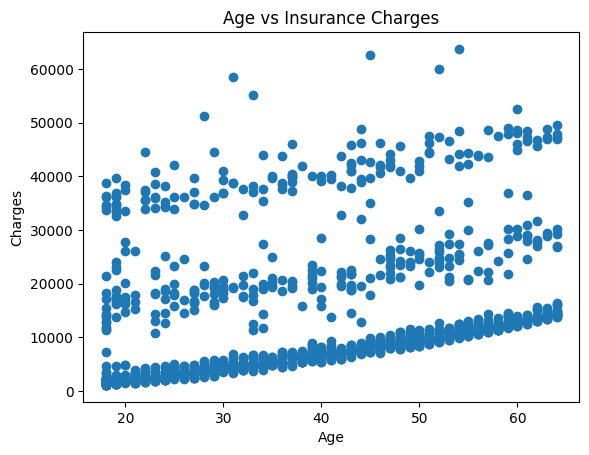

In [12]:
plt.scatter(df["age"], df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

## Insight

Insurance charges generally increase as age increases.

Older people usually have higher medical expenses, so age can be an important feature for prediction.


## 7. Visualize BMI Impact on Charges

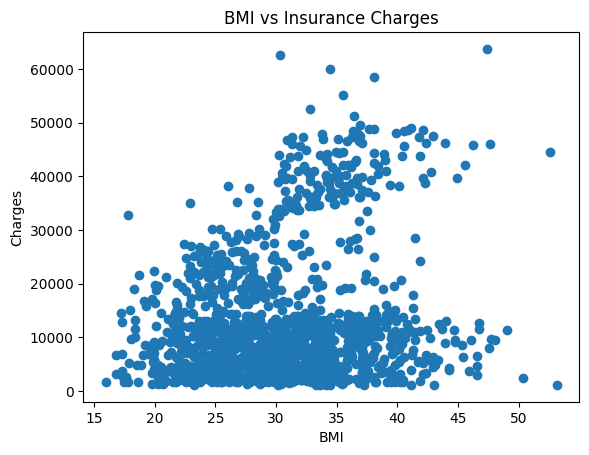

In [13]:
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## Insight

BMI has some relationship with insurance charges.

People with higher BMI may have higher medical risk, but BMI alone does not fully explain the charges.


## 8. Visualize Smoking Status Impact on Charges

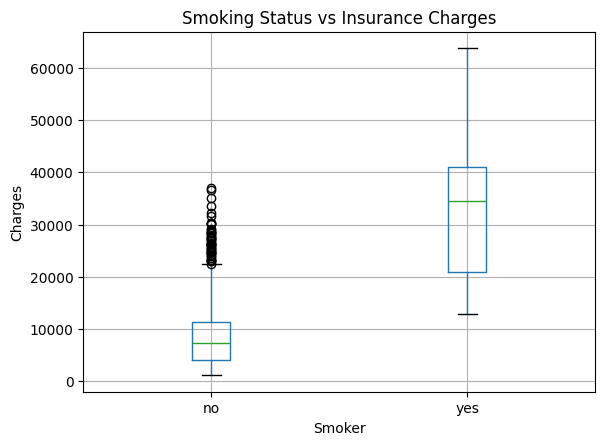

In [14]:
df.boxplot(column="charges", by="smoker")
plt.title("Smoking Status vs Insurance Charges")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

## Insight

Smoking status has a strong impact on insurance charges.

Smokers usually have much higher insurance charges compared with non-smokers.


## 9. Correlation Between Numeric Features

In [15]:
numeric_df = df[["age", "bmi", "children", "charges"]]

numeric_df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


## Explanation

Correlation shows how strongly numeric features are related to each other.

A positive value means both values increase together. A negative value means one value increases while the other decreases.


## 10. Convert Text Columns into Numbers

In [16]:
# Convert sex column
df["sex"] = df["sex"].map({"female": 0, "male": 1})

# Convert smoker column
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# Convert region column using simple one-hot encoding
df = pd.get_dummies(df, columns=["region"], drop_first=True)

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


## Explanation

Machine learning models work with numbers.

That is why we converted:
- female and male into 0 and 1
- no smoker and smoker into 0 and 1
- region into separate numeric columns


## 11. Select Input and Output Columns

In [17]:
# X contains input features
X = df.drop("charges", axis=1)

# y contains the target value
y = df["charges"]

## 12. Split Data into Training and Testing Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1070
Testing rows: 268


## Explanation

We train the model on training data.

Then we test it on new unseen testing data to check how well it performs.


## 13. Train Linear Regression Model

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Explanation

Linear Regression tries to find a straight-line relationship between input features and insurance charges.


## 14. Make Predictions

In [20]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352])

## 15. Compare Actual and Predicted Charges

In [21]:
comparison = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457
1312,4536.25900,10864.113164
899,2117.33885,170.280841
752,14210.53595,16903.450287
1286,3732.62510,1092.430936
707,10264.44210,11218.343184


## 16. Evaluate Model Using MAE and RMSE

In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 4181.194473753647
Root Mean Squared Error: 5796.284659276272


## Explanation

### MAE
MAE means **Mean Absolute Error**.

It tells us the average prediction error.

### RMSE
RMSE means **Root Mean Squared Error**.

It gives more penalty to large errors.

Lower MAE and RMSE mean better model performance.


## 17. Actual vs Predicted Charges Visualization

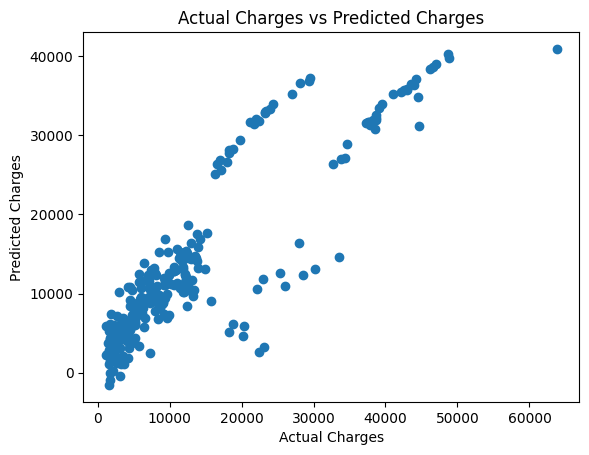

In [23]:
plt.scatter(y_test, y_pred)
plt.title("Actual Charges vs Predicted Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

## Key Insights

- Age has a positive impact on insurance charges.
- BMI can affect charges, but its impact is not as strong as smoking.
- Smokers usually have much higher medical insurance charges.
- Linear Regression can predict charges, but some predictions may have errors because medical cost data can vary a lot.
- MAE and RMSE help us understand how far predictions are from actual charges.


## Conclusion

In this project, we used personal data to estimate medical insurance claim amounts.

We cleaned and checked the dataset, visualized important features, converted text values into numbers, and trained a Linear Regression model.

The analysis shows that **smoking status**, **age**, and **BMI** are important factors in predicting insurance charges. Smoking status has the strongest visible effect because smokers usually have much higher charges than non-smokers.

The model was evaluated using **MAE** and **RMSE**. These error values show how much the predicted charges differ from the actual charges. A lower error means the model is performing better.

This model gives a basic prediction, but it can be improved further by using more advanced models and feature engineering.
